# Day 8: Improving Neural Networks

Welcome to Day 8 of the 21-Day Deep Learning Sprint. Today, we focus entirely on the art and science of improving neural networks.

Building a neural network that compiles is only the first step. Making it generalize well to unseen data requires diagnosing failure modes (like underfitting and overfitting) and systematically applying optimization and regularization techniques.

In this notebook, we will start with a simple baseline model and progressively experiment with:
* Model Capacity
* Learning Rates and Optimizers (SGD vs. Adam)
* Mini-batch training and Batch Sizes
* Weight Initialization and Activation Functions
* Batch Normalization and Dropout
* L2 Regularization (Weight Decay)
* Early Stopping and Learning-Rate Schedulers

Finally, we will combine these techniques into a single optimized network, visualize the performance trajectory, and summarize our findings in a practical comparison table.

## Setup and Dataset Preparation

We begin by importing the necessary libraries: PyTorch for neural networks, scikit-learn for dataset generation and preprocessing, and matplotlib for visualization.

We will generate a synthetic 2D dataset using `make_moons` with added noise. This dataset is non-linearly separable, making it an excellent playground for neural network experimentation. We will split the dataset into training and testing sets, and scale the features using standard scaling to ensure stable gradient flow.

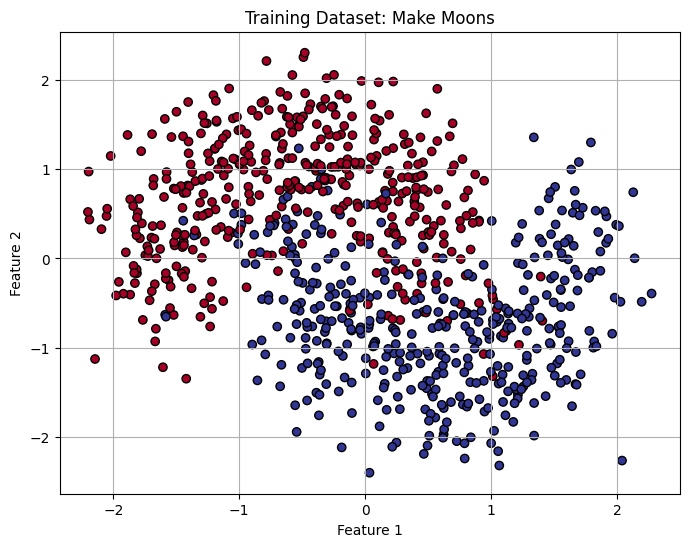

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

X, y = make_moons(n_samples=1200, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.RdYlBu, edgecolors='k')
plt.title("Training Dataset: Make Moons")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

## 1. Baseline Neural Network

We will define a simple baseline architecture. The baseline contains one tiny hidden layer with 3 neurons, uses Sigmoid activations, and starts with arbitrary default weights. It represents a restricted model that we expect will struggle with complex decision boundaries.

In [22]:
class BaselineNetwork(nn.Module):
    def __init__(self):
        super(BaselineNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 3),
            nn.Sigmoid(),
            nn.Linear(3, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

## 2. Train and Evaluate the Baseline

We define a generic evaluation function to compute accuracy. Then, we train the baseline model using standard full-batch Gradient Descent (using the entire training set at each step) with SGD for 100 epochs.

In [23]:
def calculate_accuracy(y_true, y_pred):
    predicted_classes = (y_pred >= 0.5).float()
    correct = (predicted_classes == y_true).float().sum()
    return (correct / y_true.shape[0]).item()

baseline_model = BaselineNetwork()
criterion = nn.BCELoss()
optimizer = optim.SGD(baseline_model.parameters(), lr=0.1)

baseline_train_losses = []
baseline_test_losses = []

for epoch in range(100):
    baseline_model.train()
    optimizer.zero_grad()
    predictions = baseline_model(X_train_t)
    loss = criterion(predictions, y_train_t)
    loss.backward()
    optimizer.step()

    baseline_model.eval()
    with torch.no_grad():
        test_predictions = baseline_model(X_test_t)
        test_loss = criterion(test_predictions, y_test_t)

    baseline_train_losses.append(loss.item())
    baseline_test_losses.append(test_loss.item())

baseline_model.eval()
with torch.no_grad():
    final_train_preds = baseline_model(X_train_t)
    final_test_preds = baseline_model(X_test_t)

baseline_train_acc = calculate_accuracy(y_train_t, final_train_preds)
baseline_test_acc = calculate_accuracy(y_test_t, final_test_preds)

print(f"Baseline Train Loss: {baseline_train_losses[-1]:.4f} | Train Acc: {baseline_train_acc:.4f}")
print(f"Baseline Test Loss: {baseline_test_losses[-1]:.4f} | Test Acc: {baseline_test_acc:.4f}")

Baseline Train Loss: 0.6426 | Train Acc: 0.7238
Baseline Test Loss: 0.6458 | Test Acc: 0.7222


### Interpretation: Baseline Results

The baseline model achieves moderate but suboptimal accuracy. Because of its low capacity (only 3 hidden units) and restrictive activation function (Sigmoid), it is incapable of learning a complex non-linear boundary, which leads to high bias (underfitting).

## 3. Underfitting and Overfitting

* **Underfitting (High Bias):** Occurs when the model is too simple to capture the underlying structure of the data. Both training and testing performance remain low.
* **Overfitting (High Variance):** Occurs when the model learns the noise in the training dataset rather than the true distribution. It is characterized by exceptionally low training loss but poor performance on the testing set.

We will now visualize this concept by experimenting with model capacity.

## 4. Experiment with Model Capacity

We will build a high-capacity model with multiple layers and many units per layer. To illustrate overfitting clearly, we will train this large model for 800 epochs using SGD.

In [24]:
class HighCapacityNetwork(nn.Module):
    def __init__(self):
        super(HighCapacityNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

capacity_model = HighCapacityNetwork()
optimizer_cap = optim.SGD(capacity_model.parameters(), lr=0.1)

cap_train_losses = []
cap_test_losses = []

for epoch in range(800):
    capacity_model.train()
    optimizer_cap.zero_grad()
    preds = capacity_model(X_train_t)
    loss = criterion(preds, y_train_t)
    loss.backward()
    optimizer_cap.step()

    capacity_model.eval()
    with torch.no_grad():
        test_preds = capacity_model(X_test_t)
        test_loss = criterion(test_preds, y_test_t)

    cap_train_losses.append(loss.item())
    cap_test_losses.append(test_loss.item())

capacity_model.eval()
with torch.no_grad():
    final_cap_train_preds = capacity_model(X_train_t)
    final_cap_test_preds = capacity_model(X_test_t)

cap_train_acc = calculate_accuracy(y_train_t, final_cap_train_preds)
cap_test_acc = calculate_accuracy(y_test_t, final_cap_test_preds)

print(f"Capacity Model Train Loss: {cap_train_losses[-1]:.4f} | Train Acc: {cap_train_acc:.4f}")
print(f"Capacity Model Test Loss: {cap_test_losses[-1]:.4f} | Test Acc: {cap_test_acc:.4f}")

Capacity Model Train Loss: 0.2215 | Train Acc: 0.9155
Capacity Model Test Loss: 0.2414 | Test Acc: 0.8778


### Interpretation: Model Capacity

By increasing capacity (layers and hidden units), the training loss decreases dramatically and training accuracy increases. However, notice that toward the later stages, the validation loss may plateau or rise, showing the onset of overfitting when the model's complexity is not regularized.

## 5. Experiment with Learning Rates

We will evaluate how the step size (learning rate) affects training speed and stability. We test three distinct learning rates: too small (0.001), optimal (0.1), and too large (5.0).

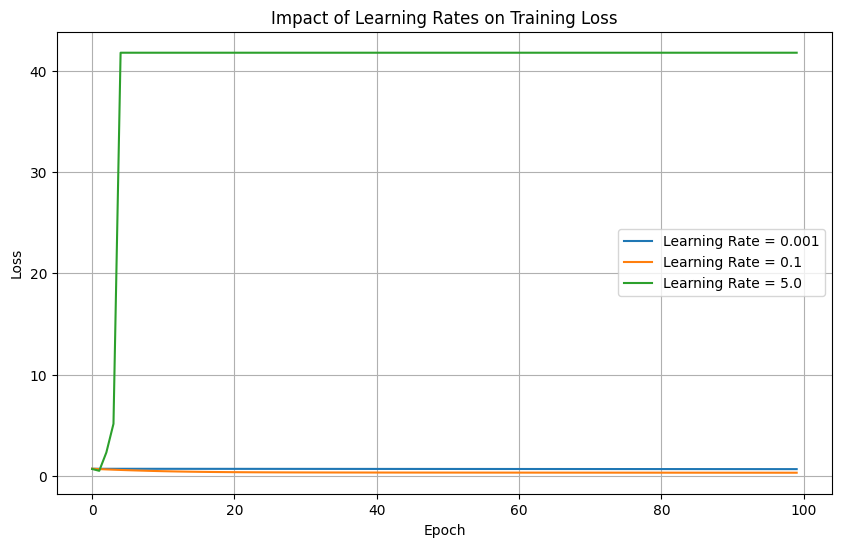

In [25]:
rates = [0.001, 0.1, 5.0]
rate_histories = {}

for lr in rates:
    model_lr = HighCapacityNetwork()
    opt = optim.SGD(model_lr.parameters(), lr=lr)
    losses = []

    for epoch in range(100):
        model_lr.train()
        opt.zero_grad()
        preds = model_lr(X_train_t)
        loss = criterion(preds, y_train_t)
        loss.backward()
        opt.step()
        losses.append(loss.item())

    rate_histories[lr] = losses

plt.figure(figsize=(10, 6))
for lr, losses in rate_histories.items():
    plt.plot(losses, label=f"Learning Rate = {lr}")
plt.title("Impact of Learning Rates on Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation: Learning Rates

* **0.001 (Too Low):** The loss drops extremely slowly. The model will require thousands of epochs to converge.
* **0.1 (Optimal):** The loss drops smoothly and converges steadily.
* **5.0 (Too High):** The loss oscillates wildly or fails to decrease as the updates are too aggressive, causing the optimizer to overshoot the minima.

## 6. Compare SGD and Adam

* **Stochastic Gradient Descent (SGD):** Updates parameters by a constant step in the negative gradient direction. It can get trapped in plateaus or saddle points.
* **Adam (Adaptive Moment Estimation):** Computes adaptive learning rates for each parameter by tracking both the first moment (mean) and second moment (uncentered variance) of the gradients.

We will compare SGD (with optimal learning rate 0.1) and Adam (with standard learning rate 0.003) on the same high-capacity network.

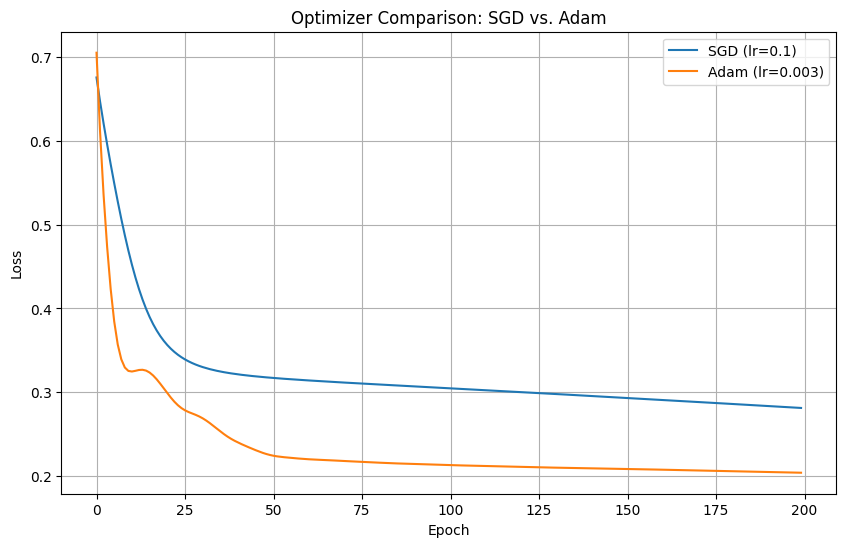

In [26]:
sgd_model = HighCapacityNetwork()
sgd_opt = optim.SGD(sgd_model.parameters(), lr=0.1)
sgd_losses = []

for epoch in range(200):
    sgd_model.train()
    sgd_opt.zero_grad()
    preds = sgd_model(X_train_t)
    loss = criterion(preds, y_train_t)
    loss.backward()
    sgd_opt.step()
    sgd_losses.append(loss.item())

adam_model = HighCapacityNetwork()
adam_opt = optim.Adam(adam_model.parameters(), lr=0.003)
adam_losses = []

for epoch in range(200):
    adam_model.train()
    adam_opt.zero_grad()
    preds = adam_model(X_train_t)
    loss = criterion(preds, y_train_t)
    loss.backward()
    adam_opt.step()
    adam_losses.append(loss.item())

plt.figure(figsize=(10, 6))
plt.plot(sgd_losses, label="SGD (lr=0.1)")
plt.plot(adam_losses, label="Adam (lr=0.003)")
plt.title("Optimizer Comparison: SGD vs. Adam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation: Optimizers

Adam converges significantly faster than standard SGD. Thanks to its adaptive momentum and scaling mechanisms, it traverses flat regions of the loss landscape much more efficiently.

## 7. Mini-Batch Training and Batch Size

Instead of calculating gradients over the entire dataset (Full Batch), we split the dataset into smaller subsets (Mini-Batches). This introduces regularization-like noise, improves memory efficiency, and speeds up the training loop.

We will build a PyTorch DataLoader and experiment with a batch size of 32.

In [27]:
dataset = TensorDataset(X_train_t, y_train_t)
batch_loader = DataLoader(dataset, batch_size=32, shuffle=True)

mb_model = HighCapacityNetwork()
mb_optimizer = optim.Adam(mb_model.parameters(), lr=0.003)
mb_losses = []

for epoch in range(50):
    mb_model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in batch_loader:
        mb_optimizer.zero_grad()
        preds = mb_model(batch_X)
        loss = criterion(preds, batch_y)
        loss.backward()
        mb_optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)
    mb_losses.append(epoch_loss / len(X_train_t))

print(f"Final Mini-Batch (Batch Size 32) Epoch Loss: {mb_losses[-1]:.4f}")

Final Mini-Batch (Batch Size 32) Epoch Loss: 0.2114


### Interpretation: Mini-batch Training

Mini-batch training converges in far fewer epochs than full-batch training because we perform multiple parameter updates per epoch (one for each batch) instead of just one.

## 8. Weight Initialization

By default, PyTorch initializes parameters using uniform distributions scaled by layer size. However, custom initializations can prevent gradients from vanishing or exploding:
* **Xavier (Glorot) Initialization:** Ideal for tanh/sigmoid activations.
* **He (Kaiming) Initialization:** Ideal for ReLU activations.

We will implement a network and apply Kaiming Normal initialization manually.

In [28]:
class InitializedNetwork(nn.Module):
    def __init__(self):
        super(InitializedNetwork, self).__init__()
        self.fc1 = nn.Linear(2, 128)
        self.fc2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        self._init_weights()

    def _init_weights(self):
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
        nn.init.zeros_(self.fc1.bias)
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity='relu')
        nn.init.zeros_(self.fc2.bias)
        nn.init.xavier_normal_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.sigmoid(self.out(x))

## 9. Activation Functions

* **Sigmoid:** Maps outputs to (0, 1). Susceptible to vanishing gradients at extreme inputs.
* **ReLU (Rectified Linear Unit):** Computes max(0, x). Solves vanishing gradients but can suffer from "dying ReLU" if units stay inactive.
* **LeakyReLU:** Introduces a small positive slope for negative inputs to prevent dead units.

We will compare ReLU and Sigmoid activations inside our model.

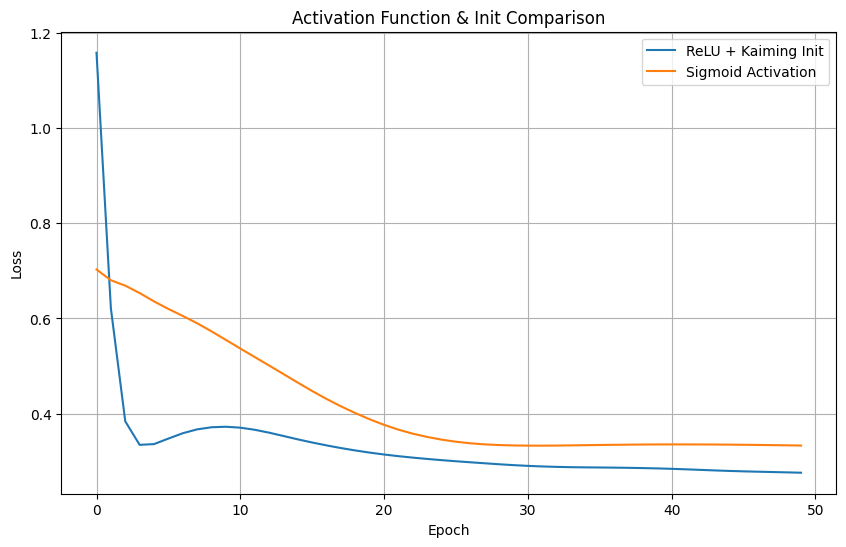

In [29]:
class SigmoidOnlyNetwork(nn.Module):
    def __init__(self):
        super(SigmoidOnlyNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 128),
            nn.Sigmoid(),
            nn.Linear(128, 128),
            nn.Sigmoid(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

init_model = InitializedNetwork()
sig_model = SigmoidOnlyNetwork()

opt_init = optim.Adam(init_model.parameters(), lr=0.003)
opt_sig = optim.Adam(sig_model.parameters(), lr=0.003)

init_losses = []
sig_losses = []

for epoch in range(50):
    init_model.train()
    opt_init.zero_grad()
    p1 = init_model(X_train_t)
    l1 = criterion(p1, y_train_t)
    l1.backward()
    opt_init.step()
    init_losses.append(l1.item())

    sig_model.train()
    opt_sig.zero_grad()
    p2 = sig_model(X_train_t)
    l2 = criterion(p2, y_train_t)
    l2.backward()
    opt_sig.step()
    sig_losses.append(l2.item())

plt.figure(figsize=(10, 6))
plt.plot(init_losses, label="ReLU + Kaiming Init")
plt.plot(sig_losses, label="Sigmoid Activation")
plt.title("Activation Function & Init Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation: Activation & Init

Using ReLU combined with Kaiming Normal initialization results in drastically faster training. The Sigmoid network suffers from saturation and diminished gradient signals, slowing down optimization.

## 10. Batch Normalization

Batch Normalization normalizes the layer inputs within each mini-batch. This keeps the distribution of activations stable throughout training (reducing internal covariate shift), allowing for higher learning rates and smoother optimization landscapes.

In [30]:
class BatchNormNetwork(nn.Module):
    def __init__(self):
        super(BatchNormNetwork, self).__init__()
        self.fc1 = nn.Linear(2, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.out = nn.Linear(128, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.relu(self.bn2(self.fc2(x)))
        return self.sigmoid(self.out(x))

## 11. Dropout

Dropout is a powerful regularization technique. During training, it randomly sets a fraction (e.g., 30%) of the input units to 0 at each step. This prevents neurons from co-adapting and forces the network to learn redundant, more robust representations.

In [31]:
class DropoutNetwork(nn.Module):
    def __init__(self):
        super(DropoutNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

## 12. L2 Regularization (Weight Decay)

L2 regularization adds a penalty proportional to the squared magnitude of the weights to the loss function. This forces weights to remain small, penalizing overly complex patterns. In PyTorch, we implement this easily using the `weight_decay` parameter in the optimizer.

In [32]:
decay_model = HighCapacityNetwork()
decay_optimizer = optim.Adam(decay_model.parameters(), lr=0.003, weight_decay=1e-4)

## 13. Early Stopping

Early stopping monitors validation loss during training and halts the training process if validation loss ceases to improve for a set number of epochs (patience). This prevents the model from spending epochs learning training-specific noise.

In [33]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

## 14. Learning-Rate Scheduling

Learning rate schedulers adjust the learning rate during training. A common strategy is to decay the learning rate when validation loss plateaus (using `ReduceLROnPlateau`), allowing the optimizer to make finer, more precise weight updates as it nears convergence.

In [34]:
sched_model = HighCapacityNetwork()
sched_optimizer = optim.Adam(sched_model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(sched_optimizer, mode='min', factor=0.1, patience=5)

## 15. The Final Improved Neural Network

We now combine all our findings into a single robust network architecture. This final network features:
* Substantial capacity (two hidden layers with 128 units each)
* Explicit Kaiming weight initialization
* ReLU activation functions
* Batch Normalization for internal stability
* Dropout (30%) to prevent over-reliance on specific neurons
* L2 Regularization (Weight Decay) inside our optimizer
* Mini-batch training (Batch Size 32)
* A Learning Rate Scheduler
* Early Stopping

In [35]:
class FinalImprovedNetwork(nn.Module):
    def __init__(self):
        super(FinalImprovedNetwork, self).__init__()
        self.fc1 = nn.Linear(2, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(128, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.drop2 = nn.Dropout(0.3)

        self.out = nn.Linear(128, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self._init_weights()

    def _init_weights(self):
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
        nn.init.zeros_(self.fc1.bias)
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity='relu')
        nn.init.zeros_(self.fc2.bias)
        nn.init.xavier_normal_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    def forward(self, x):
        x = self.drop1(self.relu(self.bn1(self.fc1(x))))
        x = self.drop2(self.relu(self.bn2(self.fc2(x))))
        return self.sigmoid(self.out(x))

### Training the Final Improved Model

We train our final model on mini-batches, monitoring validation loss for scheduler step adjustments and early stopping triggers.

In [36]:
improved_model = FinalImprovedNetwork()
improved_optimizer = optim.Adam(improved_model.parameters(), lr=0.01, weight_decay=1e-4)
improved_scheduler = optim.lr_scheduler.ReduceLROnPlateau(improved_optimizer, mode='min', factor=0.5, patience=5)
early_stopper = EarlyStopping(patience=15)

improved_train_losses = []
improved_test_losses = []

for epoch in range(300):
    improved_model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in batch_loader:
        improved_optimizer.zero_grad()
        preds = improved_model(batch_X)
        loss = criterion(preds, batch_y)
        loss.backward()
        improved_optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)

    epoch_train_loss = epoch_loss / len(X_train_t)

    improved_model.eval()
    with torch.no_grad():
        test_preds = improved_model(X_test_t)
        epoch_test_loss = criterion(test_preds, y_test_t).item()

    improved_train_losses.append(epoch_train_loss)
    improved_test_losses.append(epoch_test_loss)

    improved_scheduler.step(epoch_test_loss)
    early_stopper(epoch_test_loss)
    if early_stopper.early_stop:
        print(f"Stopped early at epoch {epoch}")
        break

improved_model.eval()
with torch.no_grad():
    final_imp_train_preds = improved_model(X_train_t)
    final_imp_test_preds = improved_model(X_test_t)

improved_train_acc = calculate_accuracy(y_train_t, final_imp_train_preds)
improved_test_acc = calculate_accuracy(y_test_t, final_imp_test_preds)

print(f"Improved Model Final Train Loss: {improved_train_losses[-1]:.4f} | Train Acc: {improved_train_acc:.4f}")
print(f"Improved Model Final Test Loss: {improved_test_losses[-1]:.4f} | Test Acc: {improved_test_acc:.4f}")

Stopped early at epoch 18
Improved Model Final Train Loss: 0.2800 | Train Acc: 0.9095
Improved Model Final Test Loss: 0.2482 | Test Acc: 0.8750


## 16 & 17. Comparison and Visualization

We will now visually compare our initial baseline model with our fully regularized, final improved network.

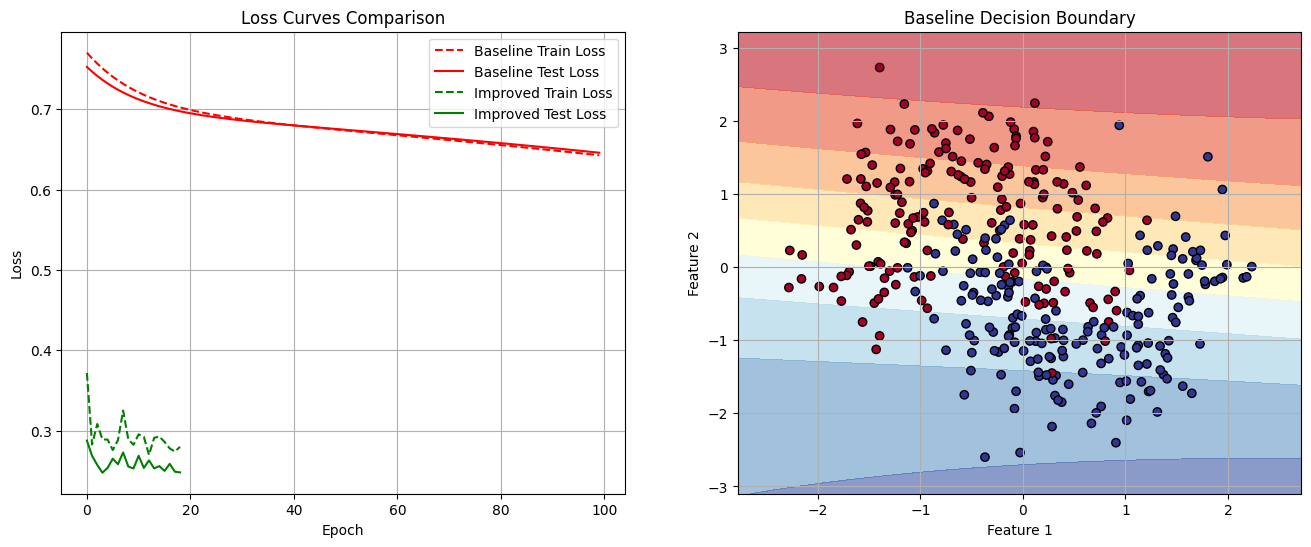

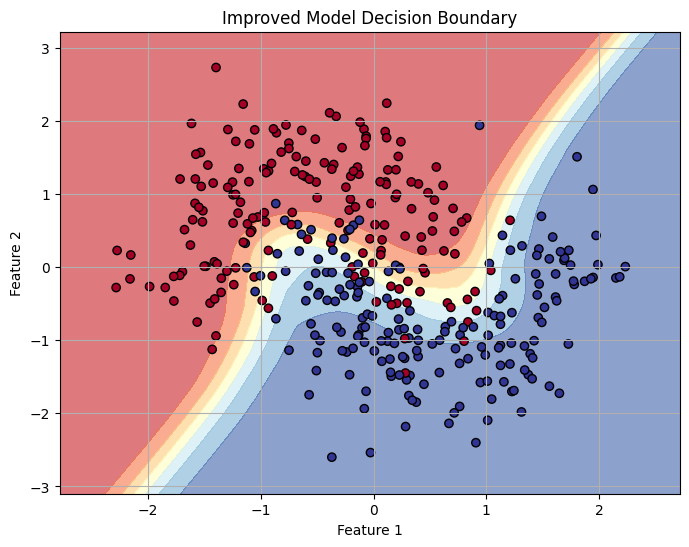

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(baseline_train_losses, label="Baseline Train Loss", linestyle="--", color="red")
axs[0].plot(baseline_test_losses, label="Baseline Test Loss", color="red")
axs[0].plot(improved_train_losses, label="Improved Train Loss", linestyle="--", color="green")
axs[0].plot(improved_test_losses, label="Improved Test Loss", color="green")
axs[0].set_title("Loss Curves Comparison")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(True)


def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    model.eval()
    with torch.no_grad():
        preds = model(grid_tensor).reshape(xx.shape).numpy()

    ax.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.6)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(True)

plot_decision_boundary(baseline_model, X_test, y_test, axs[1], "Baseline Decision Boundary")
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 6))
plot_decision_boundary(improved_model, X_test, y_test, ax2, "Improved Model Decision Boundary")
plt.show()

## 18. Experiment Comparison Table

Let's compile the metrics of all major checkpoints to analyze the overall progress of our optimization strategies.

In [38]:
import pandas as pd

results_data = {
    "Model Step": ["Baseline Model", "High Capacity (Unregularized)", "Final Improved Model"],
    "Train Loss": [baseline_train_losses[-1], cap_train_losses[-1], improved_train_losses[-1]],
    "Test Loss": [baseline_test_losses[-1], cap_test_losses[-1], improved_test_losses[-1]],
    "Train Accuracy": [baseline_train_acc, cap_train_acc, improved_train_acc],
    "Test Accuracy": [baseline_test_acc, cap_test_acc, improved_test_acc]
}

df_results = pd.DataFrame(results_data)
display(df_results)

,Model Step,Train Loss,Test Loss,Train Accuracy,Test Accuracy
0,Baseline Model,0.642610,0.645788,0.723810,0.722222
1,High Capacity (Unregularized),0.221498,0.241434,0.915476,0.877778
2,Final Improved Model,0.279992,0.248214,0.909524,0.875000


## 19. Key Takeaways and Deep Dive

### Concise Summary of Techniques

| Technique | Primary Problem Solved | When to Use |
| :--- | :--- | :--- |
| **Increased Capacity** | Underfitting (High Bias) | When training metrics/accuracy are poor on simple architectures |
| **Optimal Learning Rate** | Failure to converge / Oscillating loss | Always. Usually tune using grid search or starting from 1e-3 |
| **Adam Optimizer** | Slow training speed / local minima saddle points | Always default to Adam or AdamW for non-trivial networks |
| **Mini-batch Training** | High memory usage / slow training steps | Always. Standard sizes: 32, 64, 128 |
| **Kaiming / Xavier Initialization** | Exploding / Vanishing Gradients | Always. Matches specific activations to maintain unit variance |
| **ReLU / LeakyReLU** | Vanishing Gradient during backpropagation | Default Choice for most hidden layers |
| **Batch Normalization** | Internal Covariate Shift / unstable training | Deep networks with multiple layers |
| **Dropout** | Overfitting (High Variance) | Over-parameterized networks that fit training data perfectly but fail on validation |
| **Weight Decay (L2)** | Extreme, complex weight scales (overfitting) | Standard regularization choice |
| **Early Stopping** | Unnecessary training epochs / overfitting | Always. Saves compute and ensures optimal epoch weights are selected |
| **LR Scheduling** | Sub-optimal minima localization | Complex architectures requiring fine-tuning in late stages |

### The Interplay of Hyperparameters

Designing and stabilizing a deep learning model is a continuous balancing act between model expressivity and regularized constraints:

* **Capacity & Regularization (Dropout/Weight Decay):** If you scale up **model capacity** (more neurons or layers), you must scale up regularization (such as higher **dropout** rates or stronger **weight decay**) to prevent the model from memorizing the noise in the dataset.
* **Learning Rate & Optimizer:** The speed at which your network moves down the loss surface depends on the **optimizer** and the **learning rate**. Using an adaptive optimizer like **Adam** provides robust parameter-specific adjustments, but selecting a bad base learning rate can still cause divergence or stagnation.
* **Batch Size & Optimization:** Smaller **batch sizes** introduce more stochastic noise into the gradients, acting as a natural regularizer, while larger batch sizes provide more stable estimates but may require adjusting the learning rate higher to compensate for fewer parameter updates per epoch.
* **Initialization & Activation:** The choice of **activation functions** defines the network's capacity to represent non-linear patterns, but proper **initialization** (e.g., Kaiming for ReLU) is critical to prevent activation values from collapsing or growing infinitely in deep networks.
* **Early Stopping & Learning-Rate Scheduling:** As the validation loss begins to flatten out, **learning-rate scheduling** reduces step sizes to discover deeper minima. When no further improvement is detected, **early stopping** intervenes, serving as a backstop that guarantees training terminates at optimal generalized parameters.